# Logistic Regression: A Friendly Intro

Linear regression is great when you're predicting a *number* - a price, a temperature, a strength value. But a lot of real questions are really just **yes or no**:

- Did the coating pass the test?
- Is this email spam?
- Will the sample crack?

That's the job logistic regression was built for. In this notebook we'll:

1. make up some simple toy data
2. see why a plain straight line doesn't really work here
3. meet the "sigmoid" S-curve that fixes it
4. fit a logistic regression model
5. look at what it predicts (it's probabilities, not just 0 or 1!)
6. check how good it is

No heavy math needed - just the big picture.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams.update({"figure.dpi": 110, "font.size": 12, "axes.grid": True,
                      "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})

rng = np.random.default_rng(0)  # fixed seed, so everyone sees the same numbers

## 1. Some toy data

Imagine a simple quality check on a coating: it either **passes** (1) or **fails** (0), depending on the temperature it was cured at.

Higher temperature generally means a better chance of passing - but it's not a clean, perfect cutoff. Real life has some randomness in it too.

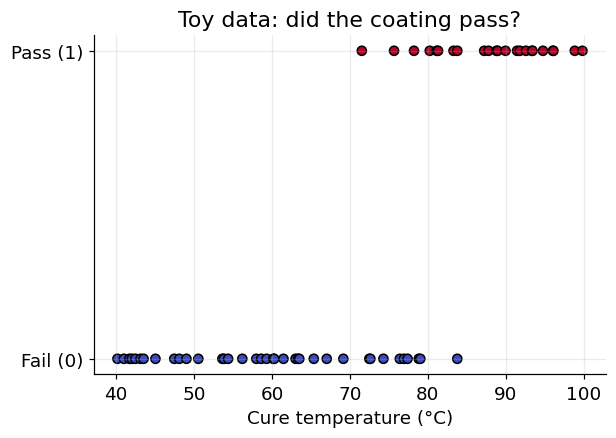

In [2]:
n = 60
cure_temp = np.sort(rng.uniform(40, 100, n))  # cure temperature in degrees C

# The TRUE (hidden) rule we're pretending exists: higher temp -> higher chance of passing
true_prob = 1 / (1 + np.exp(-(cure_temp - 70) / 6))
passed = (rng.uniform(0, 1, n) < true_prob).astype(int)  # 1 = pass, 0 = fail

plt.figure(figsize=(6, 4))
plt.scatter(cure_temp, passed, c=passed, cmap="coolwarm", edgecolor="k")
plt.yticks([0, 1], ["Fail (0)", "Pass (1)"])
plt.xlabel("Cure temperature (°C)")
plt.title("Toy data: did the coating pass?")
plt.show()

## Why not just use a straight line?

Our answer only ever takes two values: 0 or 1. Let's see what happens if we (wrongly!) fit an ordinary straight-line regression to it anyway.

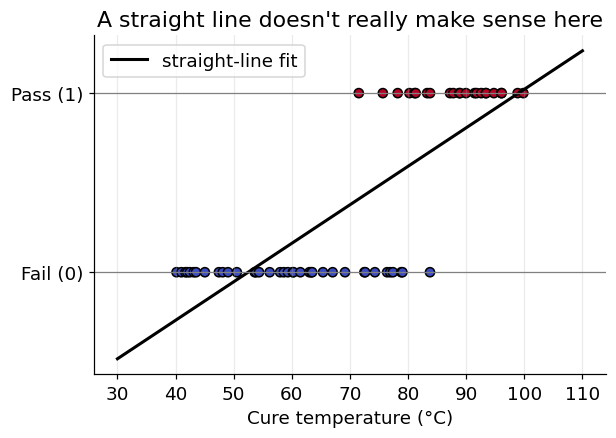

In [3]:
lin = LinearRegression().fit(cure_temp.reshape(-1, 1), passed)
grid = np.linspace(30, 110, 200).reshape(-1, 1)

plt.figure(figsize=(6, 4))
plt.scatter(cure_temp, passed, c=passed, cmap="coolwarm", edgecolor="k")
plt.plot(grid, lin.predict(grid), color="black", lw=2, label="straight-line fit")
plt.axhline(0, color="gray", lw=0.8)
plt.axhline(1, color="gray", lw=0.8)
plt.yticks([0, 1], ["Fail (0)", "Pass (1)"])
plt.xlabel("Cure temperature (°C)")
plt.legend()
plt.title("A straight line doesn't really make sense here")
plt.show()

See the problem? The line happily dips below 0 and climbs above 1. But a "probability of passing" can never be negative, and it can never be more than 100%. A straight line just isn't the right shape for this job.

What we want instead is a curve that:
- starts near 0 (very unlikely to pass)
- ends near 1 (very likely to pass)
- and never leaves that range in between

That's what the **sigmoid function** gives us.

## The sigmoid curve

Logistic regression squashes its output into a smooth S-shaped curve, always between 0 and 1:

$$ p = \frac{1}{1 + e^{-z}} $$

No matter what number `z` is - even something huge or very negative - `p` always comes out between 0 and 1. That makes it perfect for representing a probability.

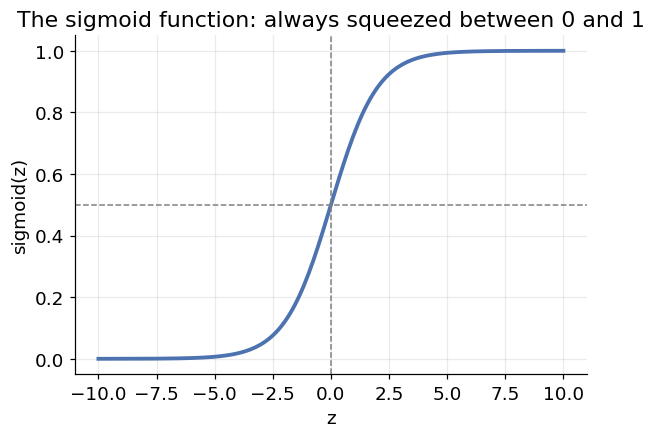

In [4]:
z = np.linspace(-10, 10, 200)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(6, 4))
plt.plot(z, sigmoid, color="#4C72B0", lw=2.5)
plt.axhline(0.5, color="gray", ls="--", lw=1)
plt.axvline(0, color="gray", ls="--", lw=1)
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("The sigmoid function: always squeezed between 0 and 1")
plt.show()

## Fitting the model

Logistic regression basically learns a straight line first (just like linear regression does - a coefficient and an intercept), and then passes that line through the sigmoid function to turn it into a proper 0-to-1 probability curve.

Let's fit it to our coating data.

In [5]:
model = LogisticRegression()
model.fit(cure_temp.reshape(-1, 1), passed)

print(f"Learned coefficient: {model.coef_[0][0]:.3f}")
print(f"Learned intercept:   {model.intercept_[0]:.3f}")

Learned coefficient: 0.309
Learned intercept:   -24.263


## What does it actually predict?

Instead of just spitting out 0 or 1, logistic regression gives you a **probability** for each temperature - how likely the coating is to pass.

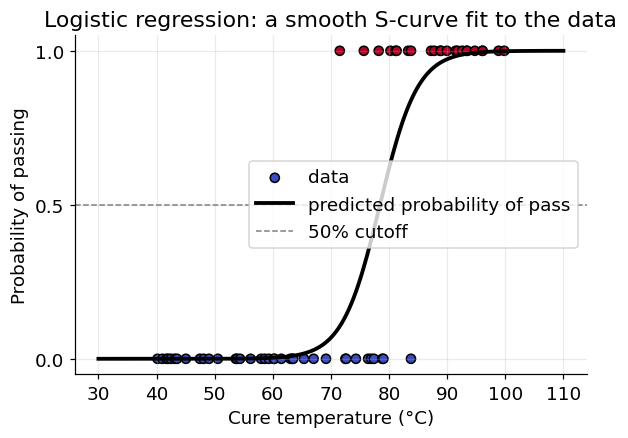

In [6]:
probs = model.predict_proba(grid)[:, 1]  # probability of "pass" (class 1)

plt.figure(figsize=(6, 4))
plt.scatter(cure_temp, passed, c=passed, cmap="coolwarm", edgecolor="k", label="data")
plt.plot(grid, probs, color="black", lw=2.5, label="predicted probability of pass")
plt.axhline(0.5, color="gray", ls="--", lw=1, label="50% cutoff")
plt.yticks([0, 0.5, 1])
plt.xlabel("Cure temperature (°C)")
plt.ylabel("Probability of passing")
plt.legend()
plt.title("Logistic regression: a smooth S-curve fit to the data")
plt.show()

## Turning probabilities into a yes/no answer

By default, if the model says the probability of passing is above 0.5, we call it a "pass" prediction. Below 0.5, we call it "fail". That crossover point is called the **decision boundary**.

In [7]:
boundary_temp = -model.intercept_[0] / model.coef_[0][0]
print(f"Decision boundary: around {boundary_temp:.1f} °C")
print("Below this temperature -> model predicts FAIL.")
print("Above this temperature -> model predicts PASS.")

Decision boundary: around 78.4 °C
Below this temperature -> model predicts FAIL.
Above this temperature -> model predicts PASS.


## How good is it?

Let's check the model's predictions against the real labels, using accuracy and a confusion matrix (a simple table of right vs. wrong guesses, broken down by class).

Accuracy on our toy data: 90.00%


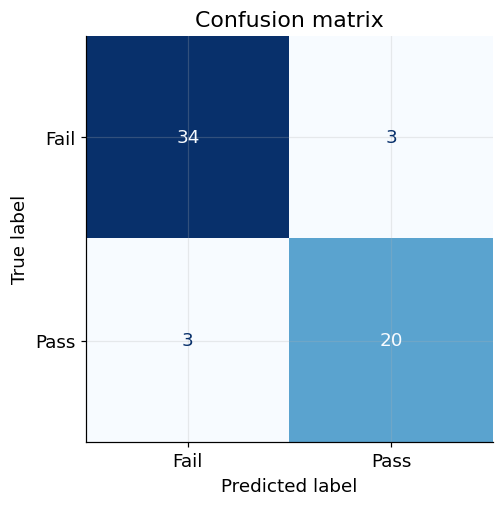

In [8]:
preds = model.predict(cure_temp.reshape(-1, 1))
acc = accuracy_score(passed, preds)
print(f"Accuracy on our toy data: {acc:.2%}")

cm = confusion_matrix(passed, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Fail", "Pass"])
disp.plot(cmap="Blues", colorbar=False)
plt.title("Confusion matrix")
plt.show()

## Quick recap  📝

- Logistic regression is for **yes/no** (or category) problems, not for predicting a raw number.
- Instead of a straight line, it fits an S-shaped curve that always stays between 0 and 1.
- That curve's output is a **probability** - e.g. "there's an 80% chance this passes."
- We turn that probability into a decision using a cutoff, usually 0.5 (though you could move it).
- Under the hood, it's still just fitting a coefficient and an intercept, like linear regression - it's simpler than the name makes it sound!

**Try it yourself:** change the cutoff from 0.5 to something else (like 0.3 or 0.7) and see how the confusion matrix changes. What does a lower cutoff mean for how "cautious" the model is?